# core

> Functions and classes used across the package

In [ ]:
#| default_exp core

In [ ]:
# | export
imported_objects  = ['np', 'pd','shutil', 'Path']
try:
    __all__.extend(imported_objects)
except:
    __all__ = imported_objects

In [ ]:
#| hide
from nbdev.showdoc import show_doc, showdoc_nm
from fastcore.docments import DocmentTbl, DocmentText, DocmentList

In [ ]:
#| export
from nbdev import showdoc
from pathlib import Path
from fastai.vision.all import set_seed

import graphviz
import matplotlib as mpl
import numpy as np
import pandas as pd
import os
import shutil
import subprocess
import sys
import torch
import warnings

## Environment Setup

In [ ]:
# | export
def mount_gdrive():
    """Mounts Google Drive to the colab environment when run on Google Colab"""
    try:
        from google.colab import drive
        drive.mount('/content/gdrive')
        print(f"Google Drive mounted successfully.")
    except:
        print('Nobebook is ran locally. No need to mount Google Drive. ')

In [ ]:
mount_gdrive()

Nobebook is ran locally. No need to mount Google Drive. 


In [ ]:
# | export
def config_fastai_for_dive(
    with_gdrive:bool=True,  # if True, mount Google Drive to the colab environment when run on Google Colab
    ):
    """Setup the nbs environment for the guided dive notebooks. This includes:

    - Ignoring warnings
    - Setting matplotlib settings
    - Setting fastai seed
    - Setting pytorch settings
    - Setting numpy and pandas settings
    - Mounting Google Drive (if on colab)
    """
    
    warnings.filterwarnings('ignore')
    
    # matplotlib settings
    mpl.rcParams['savefig.dpi']= 200
    mpl.rcParams['font.size']=12
    
    # fastai seed
    set_seed(88)
    
    # pytorch settings
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.set_printoptions(linewidth=200)

    # numpy and pandas settings
    np.set_printoptions(linewidth=200)
    pd.set_option('display.max_columns',999)

    print("Environment configured successfully.")
    # mount goggle gdrive
    if with_gdrive:
        mount_gdrive()

In [ ]:
#| echo: false
DocmentTbl(config_fastai_for_dive)

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| with_gdrive | bool | True | if True, mount Google Drive to the colab environment when run on Google Colab |

In [ ]:
config_fastai_for_dive(with_gdrive=True)

Environment configured successfully.
Nobebook is ran locally. No need to mount Google Drive. 


In [ ]:
config_fastai_for_dive(with_gdrive=False)

Environment configured successfully.


In [ ]:
# | export
def install_package(
    package_name:str, # The name of the package to install.
    ):
    """Install a Python package using pip in the current Jupyter Notebook environment. """
    try:
        # Run the pip install command
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        print(f"Package '{package_name}' installed successfully.")
    except subprocess.CalledProcessError as e:
        print(f"Failed to install package '{package_name}'. Error: {e}")

In [ ]:
#| echo: false
DocmentTbl(install_package)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| package_name | str | The name of the package to install. |

## Utilities

In [ ]:
# | export

def count_files(
    path:str | Path,   # Path to the directory containing the images, or any directory to count the number of files in it and its subdirectories. 
    ):
    """Count the number if files in the folder pointed as path, and its subfolders"""
    if isinstance(path, str): path = Path(path)
    nb_img = len([f for f in path.iterdir() if f.is_file()])
    if nb_img > 0:
        print(f"{nb_img:,d} in folder {path.name}")
    counts = {}
    for d in [d for d in path.iterdir() if d.is_dir()]:
        nb_img = len([f for f in d.iterdir() if f.is_file()])
        print(f"{nb_img:,d} in folder {d.name}")
        counts[d.name] = nb_img
    return counts

In [ ]:
#| echo: false
DocmentTbl(count_files)

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| path | str | pathlib.Path | Path to the directory containing the images, or any directory to count the number of files in it and its subdirectories. |

In [ ]:
p2images = Path('./data-dev')
count_files(p2images)

1 in folder people
0 in folder cat
1 in folder buildings


{'people': 1, 'cat': 0, 'buildings': 1}

## Graphical

In [ ]:
# | export
def _gv(code=None): 
    """Create a Graphviz source object with the given code."""
    return graphviz.Source('digraph G{ rankdir="LR"' + code + '; }')

def ml_process():
    """Setup a visual representation of the machine learning process using Graphviz."""
    code = '''ordering=in
        problem[shape=cds width=1 height=1 label="1\nFrame business problem \ninto a ML problem"]
        data[shape=cylinder width=1 height=1 label="2\nCollect, and prepare \ndata, incl. labeling"]
        modeling[shape=box3d width=1 height=1 label="3\nBuild model \nand train it"]
        evaluate[shape=component width=1 height=1 label="4\nEvaluate and \nvalidate model"]
        improve[shape=rarrow width=1 height=1 label="5\nImprove model to \nreach expected standard"]
        problem->data->modeling->evaluate->improve'''
    return _gv(code)

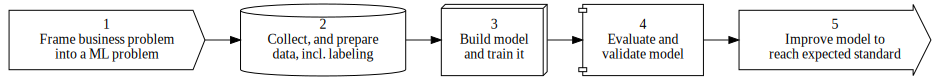

In [ ]:
ml_process()

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()